In [22]:
from astropy.wcs import WCS
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
import matplotlib.pyplot as plt

image_file = get_pkg_data_filename('combined.fits')
hdu = fits.open(image_file)[0]
wcs = WCS(hdu.header)



plt.figure(figsize=(20,20))
plt.subplot(projection=wcs, slices=('x', 'y', 0, 0))
plt.imshow(hdu.data[0,0, :,:], origin='lower') 

plt.grid(color='white', ls='solid')
plt.show()

ValueError: 'slices' should have as many elements as WCS has pixel dimensions (should be 5)

<Figure size 1440x1440 with 0 Axes>

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


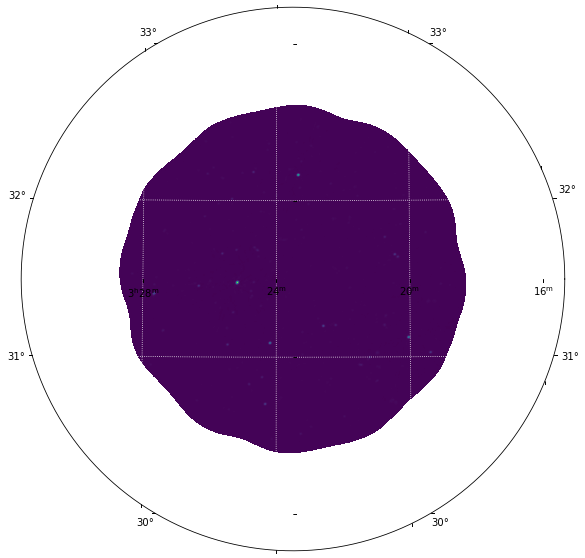

In [10]:
import matplotlib.pyplot as plt
from astropy.utils.data import get_pkg_data_filename
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes.frame import EllipticalFrame

image_file = get_pkg_data_filename('../server/source_detection/total/03:23:30.000001_+31.30.00.00000-mosaic-fieldALL-StokesI-2.5arc-5000-1e-4-spwALL-pb0.06-cyclenit500.image.fits')
image_header = fits.open(image_file)[0].header  # extract header info
image_data = fits.getdata(image_file, ext=0)

# use the WCS class to get coordinate info and projection axes to use
wcs = WCS(image_header)

plt.figure(figsize=(10,10))

# make the axes using the EllipticalFrame class
ax = plt.subplot(projection=wcs, frame_class=EllipticalFrame, slices=('x', 'y', 0, 0))

# add the image
im = ax.imshow(image_data[0,0,:,:], origin='lower')

# add a grid
overlay = ax.get_coords_overlay('fk5')
overlay.grid(color='white', ls='dotted')

In [20]:
from astropy.io import fits
import numpy as np

# List of FITS files to be combined
fits_files = [
# '../server/source_detection/total/03:23:30.000001_+31.30.00.00000-mosaic-fieldALL-StokesI-2.5arc-5000-1e-4-spwALL-pb0.06-cyclenit500.image.fits', 
              '../server/source_detection/total/03:25:30.000000_+29.29.59.99999-mosaic-fieldALL-StokesI-2.5arc-5000-1e-4-spwALL-pb0.06-cyclenit500.image.fits', 
              '../server/source_detection/total/03:32:04.530001_+31.05.04.00000-mosaic-fieldALL-StokesI-2.5arc-5000-1e-4-spwALL-pb0.06-cyclenit500.image.fits']

# Open the first FITS file to get the header information
with fits.open(fits_files[0]) as hdul:
    header = hdul[0].header
    data_shape = hdul[0].data.shape

# Create an empty array to hold the combined data
combined_data = np.zeros((len(fits_files),) + data_shape)

# Loop over each FITS file and populate the combined_data array
for i, file_name in enumerate(fits_files):
    with fits.open(file_name) as hdul:
        combined_data[i] = hdul[0].data

# Write the combined data to a new FITS file
combined_hdul = fits.HDUList([fits.PrimaryHDU(combined_data, header)])
combined_hdul.writeto('combined.fits', overwrite=True)